In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from itertools import combinations

In [19]:
def find_cluster_representatives(clustering_file_path, anime_file_path, 
                               top_n_per_cluster=5, min_score_count=50,
                               weight_score=0.7, weight_popularity=0.3):
    """
    Find representative anime titles for each cluster.
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    top_n_per_cluster : int
        Number of representative titles to return per cluster
    min_score_count : int
        Minimum number of ratings required for an anime to be considered
    weight_score : float
        Weight given to normalized score (0-1)
    weight_popularity : float
        Weight given to normalized popularity (0-1)
    
    Returns:
    --------
    dict: Dictionary with cluster IDs as keys and list of representative anime as values
    """
    
    # Load the data
    print("Loading data...")
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and prepare anime data
    print("Preparing anime data...")
    anime_df = anime_df.copy()
    
    # Handle missing values and ensure numeric types
    anime_df['score'] = pd.to_numeric(anime_df['score'], errors='coerce')
    anime_df['score_count'] = pd.to_numeric(anime_df['score_count'], errors='coerce')
    anime_df['members_count'] = pd.to_numeric(anime_df['members_count'], errors='coerce')
    
    # Filter out anime with insufficient data
    anime_df = anime_df.dropna(subset=['score', 'score_count'])
    anime_df = anime_df[anime_df['score_count'] >= min_score_count]
    
    # Merge with clustering data
    print("Merging with cluster assignments...")
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    if merged_df.empty:
        print("Warning: No matches found between clustering file and anime data!")
        return {}
    
    print(f"Found {len(merged_df)} anime with cluster assignments and sufficient rating data")
    
    # Normalize scores for ranking
    print("Calculating representative scores...")
    
    # Normalize score (0-10 scale)
    merged_df['norm_score'] = merged_df['score'] / 10.0
    
    # Normalize popularity (log scale for score_count, then normalize to 0-1)
    merged_df['log_score_count'] = np.log1p(merged_df['score_count'])
    max_log_count = merged_df['log_score_count'].max()
    merged_df['norm_popularity'] = merged_df['log_score_count'] / max_log_count
    
    # Calculate composite representative score
    merged_df['representative_score'] = (
        weight_score * merged_df['norm_score'] + 
        weight_popularity * merged_df['norm_popularity']
    )
    
    # Find top representatives for each cluster
    print("Finding cluster representatives...")
    cluster_representatives = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id].copy()
        
        # Sort by representative score
        cluster_anime = cluster_anime.sort_values('representative_score', ascending=False)
        
        # Get top N representatives
        top_anime = cluster_anime.head(top_n_per_cluster)
        
        representatives = []
        for _, anime in top_anime.iterrows():
            representatives.append({
                'anime_id': anime['anime_id'],
                'title': anime['title'],
                'score': anime['score'],
                'score_count': anime['score_count'],
                'members_count': anime['members_count'],
                'representative_score': anime['representative_score'],
                'type': anime.get('type', 'Unknown'),
                'genres': anime.get('genres', 'Unknown')
            })
        
        cluster_representatives[cluster_id] = representatives
        
        # Print summary for this cluster
        print(f"\nCluster {cluster_id} ({len(cluster_anime)} anime total):")
        for i, rep in enumerate(representatives, 1):
            print(f"  {i}. {rep['title']} (Score: {rep['score']:.2f}, "
                  f"Ratings: {rep['score_count']:,}, Rep Score: {rep['representative_score']:.3f})")
    
    return cluster_representatives

def save_representatives_to_csv(cluster_representatives, output_path):
    """
    Save cluster representatives to a CSV file.
    
    Parameters:
    -----------
    cluster_representatives : dict
        Output from find_cluster_representatives()
    output_path : str
        Path to save the CSV file
    """
    rows = []
    for cluster_id, representatives in cluster_representatives.items():
        for rank, anime in enumerate(representatives, 1):
            rows.append({
                'cluster': cluster_id,
                'rank': rank,
                'anime_id': anime['anime_id'],
                'title': anime['title'],
                'score': anime['score'],
                'score_count': anime['score_count'],
                'members_count': anime['members_count'],
                'representative_score': anime['representative_score'],
                'type': anime['type'],
                'genres': anime['genres']
            })
    
    results_df = pd.DataFrame(rows)
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")

def plot_genre_radar_charts_full_clusters(clustering_file_path, anime_file_path, 
                                         save_path=None, figsize=None, top_n_genres=10, 
                                         charts_per_figure=4, individual_charts=False,
                                         genre_weighting='weighted', max_genres_per_anime=3):
    """
    Create radar charts showing genre distributions for ENTIRE clusters (not just representatives).
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    save_path : str, optional
        Base path to save figures
    figsize : tuple, optional
        Figure size (width, height). If None, will auto-calculate for readability
    top_n_genres : int
        Number of top genres to include in radar charts
    charts_per_figure : int
        Maximum number of charts per figure (recommended: 4 for readability)
    individual_charts : bool
        If True, create separate figure for each cluster
    genre_weighting : str
        'weighted' - weight genres by 1/total_genres per anime
        'primary' - only use first N genres per anime
        'unweighted' - count all genres equally (original behavior)
    max_genres_per_anime : int
        If genre_weighting='primary', max number of genres to use per anime
    """
    
    print("Loading full cluster data...")
    # Load the data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean anime data
    anime_df = anime_df.copy()
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    
    # Merge with clustering data
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    if merged_df.empty:
        print("Warning: No matches found between clustering file and anime data!")
        return {}
    
    print(f"Analyzing {len(merged_df)} anime across {merged_df['cluster'].nunique()} clusters")
    print(f"Genre weighting method: {genre_weighting}")
    
    # Extract genre data for all clusters (using ALL anime in each cluster)
    cluster_genre_data = {}
    all_genres = set()
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        genre_counts = {}
        total_anime = len(cluster_anime)
        
        print(f"Cluster {cluster_id}: {total_anime} anime")
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                # Fix: Split by pipe "|" not comma
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]  # Remove empty strings
                
                if not genres:
                    continue
                
                # Apply genre weighting strategy
                if genre_weighting == 'primary':
                    # Only use first N genres
                    genres = genres[:max_genres_per_anime]
                    weight_per_genre = 1.0
                elif genre_weighting == 'weighted':
                    # Weight each genre by 1/total_genres for this anime
                    weight_per_genre = 1.0 / len(genres)
                else:  # unweighted
                    weight_per_genre = 1.0
                
                # Count genres with weighting
                for genre in genres:
                    if genre:
                        genre_counts[genre] = genre_counts.get(genre, 0) + weight_per_genre
                        all_genres.add(genre)
        
        # Convert counts to percentages
        genre_percentages = {genre: (count / total_anime) * 100 
                           for genre, count in genre_counts.items()}
        cluster_genre_data[cluster_id] = {
            'percentages': genre_percentages,
            'total_anime': total_anime
        }
    
    # Get top N most common genres across all clusters
    genre_totals = {}
    for cluster_data in cluster_genre_data.values():
        for genre, percentage in cluster_data['percentages'].items():
            genre_totals[genre] = genre_totals.get(genre, 0) + percentage
    
    top_genres = sorted(genre_totals.items(), key=lambda x: x[1], reverse=True)[:top_n_genres]
    selected_genres = [genre for genre, _ in top_genres]
    
    print(f"Creating radar charts for top {len(selected_genres)} genres:")
    print(f"Selected genres: {', '.join(selected_genres)}")
    
    n_clusters = len(cluster_genre_data)
    cluster_items = list(cluster_genre_data.items())
    
    if individual_charts:
        # Create individual charts for each cluster
        _create_individual_radar_charts_full(cluster_items, selected_genres, save_path, figsize)
    else:
        # Create multiple figures with limited charts per figure
        _create_grouped_radar_charts_full(cluster_items, selected_genres, save_path, 
                                        figsize, charts_per_figure, n_clusters)
    
    return selected_genres, cluster_genre_data

def analyze_genre_contexts(clustering_file_path, anime_file_path, 
                          min_pair_occurrence=10):
    """
    Analyze genre contexts - how different genres combine and their meanings.
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    min_pair_occurrence : int
        Minimum times a genre pair must occur to be analyzed
    """
    
    print("Analyzing genre contexts and combinations...")
    # Load the data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and merge
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    # Define genre contexts/themes based on common anime categorizations
    genre_contexts = {
        'High School Life': ['School', 'Romance', 'Comedy', 'Slice of Life'],
        'Dark Action': ['Action', 'Drama', 'Psychological', 'Thriller'],
        'Battle Shounen': ['Action', 'Adventure', 'Shounen', 'Supernatural'],
        'Serious Drama': ['Drama', 'Psychological', 'Mature', 'Seinen'],
        'Light Comedy': ['Comedy', 'Slice of Life', 'School', 'Romance'],
        'Dark Fantasy': ['Fantasy', 'Drama', 'Supernatural', 'Seinen'],
        'Sports Competition': ['Sports', 'Drama', 'Shounen', 'School'],
        'Mecha Action': ['Mecha', 'Action', 'Sci-Fi', 'Military'],
        'Magical Girl': ['Magic', 'Shoujo', 'Fantasy', 'Adventure'],
        'Adult Comedy': ['Comedy', 'Ecchi', 'Romance', 'Seinen'],
        'Horror Thriller': ['Horror', 'Supernatural', 'Thriller', 'Psychological'],
        'Historical Drama': ['Historical', 'Drama', 'Romance', 'Josei']
    }
    
    # Analyze genre co-occurrence patterns
    global_genre_pairs = {}
    cluster_contexts = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        
        # Track genre pairs within this cluster
        cluster_pairs = {}
        cluster_context_scores = {context: 0 for context in genre_contexts}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                
                # Count all pairs of genres in this anime
                for i in range(len(genres)):
                    for j in range(i+1, len(genres)):
                        pair = tuple(sorted([genres[i], genres[j]]))
                        cluster_pairs[pair] = cluster_pairs.get(pair, 0) + 1
                        global_genre_pairs[pair] = global_genre_pairs.get(pair, 0) + 1
                
                # Score context matches
                for context_name, context_genres in genre_contexts.items():
                    # Count how many context genres are present
                    matches = sum(1 for g in genres if g in context_genres)
                    if matches >= 2:  # Need at least 2 matching genres
                        # Weight by how complete the match is
                        context_score = matches / len(context_genres)
                        cluster_context_scores[context_name] += context_score
        
        # Normalize context scores by cluster size
        total_anime = len(cluster_anime)
        cluster_context_scores = {k: (v/total_anime)*100 for k, v in cluster_context_scores.items()}
        
        cluster_contexts[cluster_id] = {
            'top_contexts': sorted(cluster_context_scores.items(), key=lambda x: x[1], reverse=True)[:5],
            'top_pairs': sorted(cluster_pairs.items(), key=lambda x: x[1], reverse=True)[:10],
            'total_anime': total_anime
        }
    
    # Print context analysis
    print("\n" + "="*60)
    print("GENRE CONTEXT ANALYSIS")
    print("="*60)
    
    for cluster_id, data in cluster_contexts.items():
        print(f"\n--- CLUSTER {cluster_id} CONTEXTS ---")
        print(f"Total anime: {data['total_anime']}")
        
        print("\nTop Genre Contexts:")
        for context, score in data['top_contexts']:
            if score > 1:  # Only show meaningful scores
                print(f"  {score:5.1f}% - {context}")
        
        print("\nTop Genre Pairs:")
        for pair, count in data['top_pairs']:
            if count >= 3:  # Only show pairs that occur multiple times
                percentage = (count / data['total_anime']) * 100
                print(f"  {percentage:5.1f}% ({count:2d}) - {pair[0]} + {pair[1]}")
    
    return cluster_contexts, global_genre_pairs

def create_genre_context_heatmap(clustering_file_path, anime_file_path, 
                                save_path=None, figsize=(16, 10)):
    """
    Create a heatmap showing genre context distributions across clusters.
    """
    
    print("Creating genre context heatmap...")
    
    # Define meaningful genre contexts
    genre_contexts = {
        'High School Life': ['School', 'Romance', 'Comedy', 'Slice of Life'],
        'Dark Action': ['Action', 'Drama', 'Psychological', 'Thriller'], 
        'Battle Shounen': ['Action', 'Adventure', 'Shounen', 'Supernatural'],
        'Serious Drama': ['Drama', 'Psychological', 'Mature', 'Seinen'],
        'Light Comedy': ['Comedy', 'Slice of Life', 'School', 'Romance'],
        'Dark Fantasy': ['Fantasy', 'Drama', 'Supernatural', 'Seinen'],
        'Sports Drama': ['Sports', 'Drama', 'Shounen', 'School'],
        'Mecha Action': ['Mecha', 'Action', 'Sci-Fi', 'Military'],
        'Magical Girl': ['Magic', 'Shoujo', 'Fantasy', 'Adventure'],
        'Adult Comedy': ['Comedy', 'Ecchi', 'Romance', 'Seinen'],
        'Horror/Thriller': ['Horror', 'Supernatural', 'Thriller', 'Psychological'],
        'Historical': ['Historical', 'Drama', 'Romance', 'Josei'],
        'Music/Arts': ['Music', 'Drama', 'School', 'Slice of Life'],
        'Mystery/Detective': ['Mystery', 'Drama', 'Psychological', 'Seinen']
    }
    
    # Load and process data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    # Calculate context scores for each cluster
    cluster_context_matrix = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        context_scores = {context: 0 for context in genre_contexts}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                
                # Score each context
                for context_name, context_genres in genre_contexts.items():
                    matches = sum(1 for g in genres if g in context_genres)
                    if matches >= 2:  # Need at least 2 matching genres
                        # Weight by completeness and presence
                        context_score = (matches / len(context_genres)) * (matches / len(genres))
                        context_scores[context_name] += context_score
        
        # Normalize by cluster size
        total_anime = len(cluster_anime)
        context_scores = {k: (v/total_anime)*100 for k, v in context_scores.items()}
        cluster_context_matrix[cluster_id] = context_scores
    
    # Create heatmap data
    cluster_ids = sorted(cluster_context_matrix.keys())
    context_names = list(genre_contexts.keys())
    
    matrix_data = []
    for cluster_id in cluster_ids:
        row = [cluster_context_matrix[cluster_id][context] for context in context_names]
        matrix_data.append(row)
    
    # Create the heatmap
    plt.figure(figsize=figsize)
    
    df_heatmap = pd.DataFrame(matrix_data,
                             index=[f'Cluster {cid}' for cid in cluster_ids],
                             columns=context_names)
    
    sns.heatmap(df_heatmap, annot=True, cmap='YlOrRd', fmt='.1f',
                cbar_kws={'label': 'Context Strength (%)'})
    
    plt.title('Genre Context Distribution Across Clusters', fontsize=16, fontweight='bold')
    plt.xlabel('Genre Contexts', fontsize=14)
    plt.ylabel('Clusters', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Context heatmap saved to {save_path}")
    
    plt.show()
    
    return df_heatmap

def discover_genre_patterns_data_driven(clustering_file_path, anime_file_path,
                                       min_support=0.05, min_confidence=0.3):
    """
    Discover genre patterns automatically from the data using association rule mining.
    No predefined archetypes - let the data reveal its own patterns!
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    min_support : float
        Minimum support for frequent itemsets (% of cluster that must have pattern)
    min_confidence : float
        Minimum confidence for association rules
    """
    
    print("Discovering genre patterns from data (no predefined archetypes)...")
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_patterns = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        
        # Create transaction matrix (each anime = transaction, genres = items)
        transactions = []
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                transactions.append(set(genres))
        
        # Find frequent itemsets (genre combinations that appear often)
        frequent_patterns = find_frequent_itemsets(transactions, min_support)
        
        # Find association rules (if A then B)
        association_rules = find_association_rules(transactions, frequent_patterns, min_confidence)
        
        # Statistical significance testing
        significant_pairs = find_statistically_significant_pairs(transactions)
        
        cluster_patterns[cluster_id] = {
            'total_anime': len(cluster_anime),
            'frequent_patterns': frequent_patterns,
            'association_rules': association_rules,
            'significant_pairs': significant_pairs
        }
        
        print(f"\n--- CLUSTER {cluster_id} DATA-DRIVEN PATTERNS ---")
        print(f"Total anime: {len(cluster_anime)}")
        
        print(f"\nFrequent Genre Combinations (≥{min_support*100:.0f}% of cluster):")
        for pattern, support in frequent_patterns[:10]:
            print(f"  {support:.1%} - {' + '.join(sorted(pattern))}")
        
        print(f"\nAssociation Rules (confidence ≥{min_confidence:.1%}):")
        for rule in association_rules[:8]:
            antecedent, consequent, confidence, lift = rule
            print(f"  {' + '.join(sorted(antecedent))} → {' + '.join(sorted(consequent))} "
                  f"(conf: {confidence:.1%}, lift: {lift:.2f})")
        
        print(f"\nStatistically Significant Genre Pairs:")
        for pair, p_value, observed, expected in significant_pairs[:8]:
            print(f"  {pair[0]} + {pair[1]} (p={p_value:.3f}, obs={observed:.1%}, exp={expected:.1%})")
    
    return cluster_patterns

def find_frequent_itemsets(transactions, min_support):
    """Find genre combinations that appear frequently together."""
    from itertools import combinations
    
    # Count all items (genres)
    all_genres = set()
    for transaction in transactions:
        all_genres.update(transaction)
    
    n_transactions = len(transactions)
    min_count = int(min_support * n_transactions)
    
    frequent_patterns = []
    
    # Check individual genres
    for genre in all_genres:
        count = sum(1 for transaction in transactions if genre in transaction)
        if count >= min_count:
            frequent_patterns.append(({genre}, count / n_transactions))
    
    # Check pairs
    for genre1, genre2 in combinations(all_genres, 2):
        count = sum(1 for transaction in transactions 
                   if genre1 in transaction and genre2 in transaction)
        if count >= min_count:
            frequent_patterns.append(({genre1, genre2}, count / n_transactions))
    
    # Check triplets (only if we have enough data)
    if n_transactions > 50:
        for genre1, genre2, genre3 in combinations(all_genres, 3):
            count = sum(1 for transaction in transactions 
                       if all(g in transaction for g in [genre1, genre2, genre3]))
            if count >= min_count:
                frequent_patterns.append(({genre1, genre2, genre3}, count / n_transactions))
    
    # Sort by support (frequency)
    frequent_patterns.sort(key=lambda x: x[1], reverse=True)
    return frequent_patterns

def find_association_rules(transactions, frequent_patterns, min_confidence):
    """Find rules like 'if Action then Adventure' with high confidence."""
    from itertools import combinations
    
    rules = []
    n_transactions = len(transactions)
    
    # Only consider patterns with 2+ items
    multi_item_patterns = [(pattern, support) for pattern, support in frequent_patterns 
                          if len(pattern) >= 2]
    
    for pattern, pattern_support in multi_item_patterns:
        pattern_list = list(pattern)
        
        # Try different splits of the pattern into antecedent → consequent
        for r in range(1, len(pattern_list)):
            for antecedent in combinations(pattern_list, r):
                antecedent = set(antecedent)
                consequent = pattern - antecedent
                
                # Calculate support of antecedent
                antecedent_count = sum(1 for transaction in transactions 
                                     if antecedent.issubset(transaction))
                
                if antecedent_count > 0:
                    confidence = pattern_support / (antecedent_count / n_transactions)
                    
                    # Calculate lift (how much more likely than random)
                    consequent_count = sum(1 for transaction in transactions 
                                         if consequent.issubset(transaction))
                    consequent_prob = consequent_count / n_transactions
                    lift = confidence / consequent_prob if consequent_prob > 0 else 0
                    
                    if confidence >= min_confidence and lift > 1.0:
                        rules.append((antecedent, consequent, confidence, lift))
    
    # Sort by confidence * lift
    rules.sort(key=lambda x: x[2] * x[3], reverse=True)
    return rules

def find_statistically_significant_pairs(transactions):
    """Find genre pairs that appear together more than random chance."""
    from itertools import combinations
    from scipy.stats import chi2_contingency
    import numpy as np
    
    # Get all genres
    all_genres = set()
    for transaction in transactions:
        all_genres.update(transaction)
    
    all_genres = list(all_genres)
    n_transactions = len(transactions)
    significant_pairs = []
    
    # Test each pair for statistical significance
    for genre1, genre2 in combinations(all_genres, 2):
        # Create contingency table
        both = sum(1 for t in transactions if genre1 in t and genre2 in t)
        genre1_only = sum(1 for t in transactions if genre1 in t and genre2 not in t)
        genre2_only = sum(1 for t in transactions if genre1 not in t and genre2 in t)
        neither = sum(1 for t in transactions if genre1 not in t and genre2 not in t)
        
        # Contingency table: [[both, genre1_only], [genre2_only, neither]]
        contingency_table = np.array([[both, genre1_only], 
                                     [genre2_only, neither]])
        
        # Skip if any cell has too few observations
        if np.min(contingency_table) >= 5:
            try:
                chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                
                # Calculate observed vs expected rates
                observed_rate = both / n_transactions
                expected_rate = expected[0, 0] / n_transactions
                
                # Only include if significantly higher than expected
                if p_value < 0.05 and observed_rate > expected_rate:
                    significant_pairs.append(((genre1, genre2), p_value, 
                                            observed_rate, expected_rate))
            except:
                continue
    
    # Sort by p-value (most significant first)
    significant_pairs.sort(key=lambda x: x[1])
    return significant_pairs

def cluster_genre_combinations_automatically(clustering_file_path, anime_file_path,
                                           n_clusters_for_combos=5):
    """
    Automatically cluster genre combinations to find natural groupings.
    Uses unsupervised learning to discover patterns without bias.
    """
    
    print("Automatically clustering genre combinations...")
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    from sklearn.feature_extraction.text import CountVectorizer
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    
    cluster_results = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        
        if len(cluster_anime) < 20:  # Skip small clusters
            continue
            
        # Prepare genre combination strings
        genre_combinations = []
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                # Sort genres for consistency
                genre_combinations.append(' '.join(sorted(genres)))
        
        # Vectorize genre combinations
        vectorizer = CountVectorizer(min_df=2, token_pattern=r'\b\w+\b')
        try:
            genre_matrix = vectorizer.fit_transform(genre_combinations)
            
            # Cluster the genre combinations
            n_combo_clusters = min(n_clusters_for_combos, len(set(genre_combinations)))
            if n_combo_clusters > 1:
                kmeans = KMeans(n_clusters=n_combo_clusters, random_state=42)
                combo_labels = kmeans.fit_predict(genre_matrix.toarray())
                
                # Analyze each genre combination cluster
                combo_clusters = {}
                for i in range(n_combo_clusters):
                    combo_indices = [j for j, label in enumerate(combo_labels) if label == i]
                    combo_examples = [genre_combinations[j] for j in combo_indices]
                    
                    # Find most common genres in this combo cluster
                    all_genres_in_combo = []
                    for combo in combo_examples:
                        all_genres_in_combo.extend(combo.split())
                    
                    genre_counts = {}
                    for genre in all_genres_in_combo:
                        genre_counts[genre] = genre_counts.get(genre, 0) + 1
                    
                    top_genres = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:5]
                    
                    combo_clusters[i] = {
                        'size': len(combo_examples),
                        'top_genres': top_genres,
                        'examples': combo_examples[:5]  # First 5 examples
                    }
                
                cluster_results[cluster_id] = combo_clusters
                
                print(f"\n--- CLUSTER {cluster_id} AUTO-DISCOVERED GENRE GROUPINGS ---")
                for combo_cluster_id, data in combo_clusters.items():
                    print(f"\nGenre Grouping {combo_cluster_id} ({data['size']} anime):")
                    print(f"  Common genres: {', '.join([f'{g}({c})' for g, c in data['top_genres']])}")
                    print(f"  Examples: {data['examples'][:3]}")
        
        except Exception as e:
            print(f"Could not analyze cluster {cluster_id}: {e}")
            continue
    
def create_clean_cluster_summary(clustering_file_path, anime_file_path, 
                               save_path=None):
    """
    Create a clean, interpretable summary of cluster characteristics.
    Combines predefined archetypes with key data-driven insights.
    """
    
    print("Creating clean cluster summary...")
    
    # Get both predefined and data-driven results
    archetype_results = identify_cluster_archetypes(clustering_file_path, anime_file_path)
    
    # Load data for simple analysis
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    print("\n" + "="*60)
    print("CLEAN CLUSTER SUMMARY")
    print("="*60)
    
    cluster_summaries = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        total_anime = len(cluster_anime)
        
        # Get top individual genres (simple count)
        all_genres = []
        top_combinations = {}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                all_genres.extend(genres)
                
                # Track most common exact combinations
                combo = '|'.join(sorted(genres[:3]))  # Top 3 genres only
                top_combinations[combo] = top_combinations.get(combo, 0) + 1
        
        # Top individual genres
        genre_counts = pd.Series(all_genres).value_counts()
        top_genres = [(genre, (count/total_anime)*100) 
                     for genre, count in genre_counts.head(5).items()]
        
        # Top combinations (simplified)
        top_combos = sorted(top_combinations.items(), key=lambda x: x[1], reverse=True)[:3]
        top_combos = [(combo, (count/total_anime)*100) for combo, count in top_combos]
        
        # Get archetype from predefined analysis
        if cluster_id in archetype_results:
            top_archetype = archetype_results[cluster_id]['top_archetypes'][0] if archetype_results[cluster_id]['top_archetypes'] else ("Unknown", 0)
        else:
            top_archetype = ("Unknown", 0)
        
        # Simple characterization
        primary_genres = [g for g, p in top_genres[:3]]
        if len(primary_genres) >= 2:
            simple_description = f"{primary_genres[0]} + {primary_genres[1]}"
            if len(primary_genres) >= 3:
                simple_description += f" + {primary_genres[2]}"
        else:
            simple_description = primary_genres[0] if primary_genres else "Mixed"
        
        cluster_summaries[cluster_id] = {
            'size': total_anime,
            'description': simple_description,
            'archetype': top_archetype[0],
            'top_genres': top_genres,
            'top_combinations': top_combos
        }
        
        print(f"\n🎯 CLUSTER {cluster_id} ({total_anime} anime)")
        print(f"   Primary Type: {simple_description}")
        print(f"   Best Archetype Match: {top_archetype[0]} ({top_archetype[1]:.1f})")
        print(f"   Top Genres: {', '.join([f'{g} ({p:.1f}%)' for g, p in top_genres[:3]])}")
        print(f"   Common Combinations:")
        for combo, pct in top_combos:
            print(f"     • {combo.replace('|', ' + ')} ({pct:.1f}%)")
    
    # Create a comparison table
    print(f"\n" + "="*60)
    print("CLUSTER COMPARISON TABLE")
    print("="*60)
    print(f"{'Cluster':<8} {'Size':<6} {'Primary Type':<25} {'Top Archetype':<20}")
    print("-" * 60)
    
    for cluster_id, data in cluster_summaries.items():
        print(f"{cluster_id:<8} {data['size']:<6} {data['description']:<25} {data['archetype']:<20}")
    
    # Identify unique clusters
    print(f"\n" + "="*60)
    print("KEY INSIGHTS")
    print("="*60)
    
    # Find the most distinctive clusters
    all_descriptions = [data['description'] for data in cluster_summaries.values()]
    unique_patterns = set(all_descriptions)
    
    print(f"📊 Found {len(unique_patterns)} distinct anime patterns across {len(cluster_summaries)} clusters")
    
    # Size analysis
    sizes = [data['size'] for data in cluster_summaries.values()]
    print(f"📈 Cluster sizes range from {min(sizes)} to {max(sizes)} anime (avg: {np.mean(sizes):.1f})")
    
    # Pattern analysis
    romance_clusters = [cid for cid, data in cluster_summaries.items() if 'Romance' in data['description']]
    action_clusters = [cid for cid, data in cluster_summaries.items() if 'Action' in data['description']]
    comedy_clusters = [cid for cid, data in cluster_summaries.items() if 'Comedy' in data['description']]
    
    print(f"💕 Romance-focused clusters: {romance_clusters}")
    print(f"⚔️  Action-focused clusters: {action_clusters}")
    print(f"😂 Comedy-focused clusters: {comedy_clusters}")
    
    # Save summary if requested
    if save_path:
        summary_lines = []
        summary_lines.append("ANIME CLUSTER SUMMARY")
        summary_lines.append("=" * 50)
        
        for cluster_id, data in cluster_summaries.items():
            summary_lines.append(f"\nCluster {cluster_id}: {data['description']} ({data['size']} anime)")
            summary_lines.append(f"  Archetype: {data['archetype']}")
            summary_lines.append(f"  Top genres: {', '.join([f'{g} ({p:.1f}%)' for g, p in data['top_genres'][:3]])}")
        
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(summary_lines))
        print(f"\n📄 Summary saved to {save_path}")
    
    return cluster_summaries

def create_simple_genre_patterns(clustering_file_path, anime_file_path):
    """
    Simple, clean analysis of genre patterns without complex clustering.
    Avoids the multi-word genre splitting bug completely.
    """
    
    print("Analyzing genre patterns (simple approach, no word splitting)...")
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    print("\n" + "="*60)
    print("SIMPLE GENRE PATTERN ANALYSIS")
    print("="*60)
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        total_anime = len(cluster_anime)
        
        # Track individual genres and combinations
        individual_genres = {}
        two_genre_combos = {}
        three_genre_combos = {}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                # Split properly by pipe and keep complete genres
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                
                # Count individual genres
                for genre in genres:
                    individual_genres[genre] = individual_genres.get(genre, 0) + 1
                
                # Count 2-genre combinations
                if len(genres) >= 2:
                    for i in range(len(genres)):
                        for j in range(i+1, len(genres)):
                            combo = tuple(sorted([genres[i], genres[j]]))
                            two_genre_combos[combo] = two_genre_combos.get(combo, 0) + 1
                
                # Count 3-genre combinations (most common)
                if len(genres) >= 3:
                    combo = tuple(sorted(genres[:3]))  # First 3 genres
                    three_genre_combos[combo] = three_genre_combos.get(combo, 0) + 1
        
        # Get top results
        top_individual = sorted(individual_genres.items(), key=lambda x: x[1], reverse=True)[:5]
        top_pairs = sorted(two_genre_combos.items(), key=lambda x: x[1], reverse=True)[:5]
        top_triples = sorted(three_genre_combos.items(), key=lambda x: x[1], reverse=True)[:3]
        
        print(f"\n🎯 CLUSTER {cluster_id} ({total_anime} anime)")
        
        print(f"   Top Individual Genres:")
        for genre, count in top_individual:
            pct = (count / total_anime) * 100
            print(f"     • {genre}: {pct:.1f}% ({count} anime)")
        
        print(f"   Common Genre Pairs:")
        for combo, count in top_pairs:
            pct = (count / total_anime) * 100
            print(f"     • {combo[0]} + {combo[1]}: {pct:.1f}% ({count} anime)")
        
        print(f"   Common 3-Genre Patterns:")
        for combo, count in top_triples:
            pct = (count / total_anime) * 100
            combo_str = " + ".join(combo)
            print(f"     • {combo_str}: {pct:.1f}% ({count} anime)")

def create_cluster_signature_summary(clustering_file_path, anime_file_path):
    """
    Create a signature/fingerprint for each cluster based on its most distinctive genres.
    """
    
    print("\n" + "="*60)
    print("CLUSTER SIGNATURE ANALYSIS")
    print("="*60)
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    # Calculate global genre frequencies
    all_genres = []
    total_anime = len(merged_df)
    
    for _, anime in merged_df.iterrows():
        if anime['genres']:
            genres = [g.strip() for g in str(anime['genres']).split('|')]
            genres = [g for g in genres if g]
            all_genres.extend(genres)
    
    global_genre_freq = {}
    for genre in all_genres:
        global_genre_freq[genre] = global_genre_freq.get(genre, 0) + 1
    
    # Calculate cluster signatures
    cluster_signatures = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        cluster_size = len(cluster_anime)
        
        # Count genres in this cluster
        cluster_genres = {}
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]
                for genre in genres:
                    cluster_genres[genre] = cluster_genres.get(genre, 0) + 1
        
        # Calculate enrichment scores (cluster % vs global %)
        enrichment_scores = {}
        for genre, cluster_count in cluster_genres.items():
            cluster_pct = (cluster_count / cluster_size) * 100
            global_pct = (global_genre_freq[genre] / total_anime) * 100
            enrichment = cluster_pct / global_pct if global_pct > 0 else 0
            
            # Only include genres that are significantly enriched (>1.5x global) and present in at least 10% of cluster
            if enrichment > 1.5 and cluster_pct > 10:
                enrichment_scores[genre] = {
                    'enrichment': enrichment,
                    'cluster_pct': cluster_pct,
                    'global_pct': global_pct
                }
        
        # Get top enriched genres (most distinctive for this cluster)
        top_signatures = sorted(enrichment_scores.items(), 
                               key=lambda x: x[1]['enrichment'], reverse=True)[:4]
        
        cluster_signatures[cluster_id] = {
            'size': cluster_size,
            'signatures': top_signatures
        }
        
        print(f"\n🔍 CLUSTER {cluster_id} SIGNATURE ({cluster_size} anime)")
        if top_signatures:
            for genre, data in top_signatures:
                print(f"   • {genre}: {data['cluster_pct']:.1f}% here vs {data['global_pct']:.1f}% globally "
                      f"({data['enrichment']:.1f}x enriched)")
        else:
            print("   • No strong signatures (mixed genres)")
    
    return cluster_signatures

def get_ultra_simple_cluster_names(clustering_file_path, anime_file_path):
    """
    Generate dead simple 1-2 word names for each cluster.
    """
    
    # Get signatures
    signatures = create_cluster_signature_summary(clustering_file_path, anime_file_path)
    
    print(f"\n" + "="*50)
    print("ULTRA-SIMPLE CLUSTER NAMES")
    print("="*50)
    
    cluster_names = {}
    
    for cluster_id, data in signatures.items():
        if data['signatures']:
            # Use top 1-2 signature genres
            top_genres = [genre for genre, _ in data['signatures'][:2]]
            
            if len(top_genres) == 1:
                simple_name = top_genres[0]
            else:
                simple_name = f"{top_genres[0]} + {top_genres[1]}"
        else:
            simple_name = "Mixed"
        
        cluster_names[cluster_id] = simple_name
        size_desc = "large" if data['size'] > 150 else "medium" if data['size'] > 100 else "small"
        
        print(f"   Cluster {cluster_id}: {simple_name} ({size_desc}, {data['size']} anime)")
    
    return cluster_names

def debug_archetype_scoring(clustering_file_path, anime_file_path, cluster_id=2):
    """
    Debug why "Dark Fantasy" is dominating when it should be a small percentage.
    """
    
    print(f"🔍 DEBUGGING ARCHETYPE SCORING FOR CLUSTER {cluster_id}")
    print("="*60)
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
    
    # Check Dark Fantasy archetype specifically
    dark_fantasy_pattern = {'required': ['Fantasy'], 'bonus': ['Drama', 'Supernatural', 'Seinen', 'Action']}
    
    fantasy_count = 0
    dark_fantasy_scores = []
    all_scores = []
    
    print(f"Cluster {cluster_id} has {len(cluster_anime)} anime")
    print(f"Dark Fantasy pattern: Fantasy required + bonus: {dark_fantasy_pattern['bonus']}")
    print()
    
    for i, (_, anime) in enumerate(cluster_anime.iterrows()):
        if anime['genres']:
            genres = set(g.strip() for g in str(anime['genres']).split('|') if g.strip())
            
            # Count fantasy anime
            if 'Fantasy' in genres:
                fantasy_count += 1
            
            # Calculate Dark Fantasy score for this anime
            score = 0
            required_matches = sum(1 for req in dark_fantasy_pattern['required'] if req in genres)
            
            if required_matches == len(dark_fantasy_pattern['required']):  # Has Fantasy
                score += 10  # Base score
                
                # Bonus points
                bonus_matches = sum(1 for bonus in dark_fantasy_pattern['bonus'] if bonus in genres)
                score += bonus_matches * 2
                
                # Penalty for unrelated genres
                all_pattern_genres = set(dark_fantasy_pattern['required'] + dark_fantasy_pattern['bonus'])
                unrelated_genres = len(genres - all_pattern_genres)
                score -= unrelated_genres * 0.5
                
                score = max(score, 0)
                
                if score > 0:
                    dark_fantasy_scores.append(score)
                    if i < 5:  # Show first few examples
                        print(f"  Example {i+1}: {list(genres)}")
                        print(f"    Bonus matches: {[g for g in dark_fantasy_pattern['bonus'] if g in genres]}")
                        print(f"    Unrelated genres: {list(genres - all_pattern_genres)}")
                        print(f"    Score: {score}")
                        print()
            
            all_scores.append(score)
    
    total_fantasy_pct = (fantasy_count / len(cluster_anime)) * 100
    avg_dark_fantasy_score = sum(all_scores) / len(cluster_anime)
    
    print(f"📊 RESULTS:")
    print(f"  Fantasy anime in cluster: {fantasy_count}/{len(cluster_anime)} ({total_fantasy_pct:.1f}%)")
    print(f"  Anime with Dark Fantasy scores > 0: {len(dark_fantasy_scores)}")
    print(f"  Average Dark Fantasy score: {avg_dark_fantasy_score:.2f}")
    print(f"  Average score among Fantasy anime: {np.mean(dark_fantasy_scores) if dark_fantasy_scores else 0:.2f}")
    
    print(f"\n🚨 THE PROBLEM:")
    if total_fantasy_pct < 50 and avg_dark_fantasy_score > 2:
        print(f"  Only {total_fantasy_pct:.1f}% of cluster is Fantasy, but average Dark Fantasy score is {avg_dark_fantasy_score:.2f}")
        print(f"  This suggests the archetype scoring system is BROKEN!")
        print(f"  Fantasy anime are getting high scores and inflating the cluster average.")
    
    return avg_dark_fantasy_score, total_fantasy_pct

def fix_archetype_scoring(clustering_file_path, anime_file_path):
    """
    Fixed archetype scoring that requires MAJORITY presence, not just high scores among minority.
    """
    
    print("🔧 FIXED ARCHETYPE SCORING")
    print("="*50)
    
    archetype_patterns = {
        'High School Romance': {'required': ['School', 'Romance'], 'bonus': ['Comedy', 'Slice of Life']},
        'Battle Shounen': {'required': ['Action', 'Shounen'], 'bonus': ['Adventure', 'Supernatural', 'Fantasy']},
        'Psychological Thriller': {'required': ['Psychological'], 'bonus': ['Thriller', 'Drama', 'Mystery']},
        'Slice of Life Comedy': {'required': ['Slice of Life', 'Comedy'], 'bonus': ['School', 'Seinen']},
        'Dark Fantasy': {'required': ['Fantasy'], 'bonus': ['Drama', 'Supernatural', 'Seinen', 'Action']},
        'Sports Drama': {'required': ['Sports'], 'bonus': ['Drama', 'School', 'Shounen']},
        'Mecha Military': {'required': ['Mecha'], 'bonus': ['Military', 'Action', 'Sci-Fi']},
        'Magical Girl': {'required': ['Magic'], 'bonus': ['Shoujo', 'Fantasy', 'Adventure']},
        'Adult Romance': {'required': ['Romance'], 'bonus': ['Seinen', 'Josei', 'Drama']},
        'Horror Supernatural': {'required': ['Horror'], 'bonus': ['Supernatural', 'Thriller']},
        'Historical Drama': {'required': ['Historical'], 'bonus': ['Drama', 'Romance']},
        'Music/Idol': {'required': ['Music'], 'bonus': ['School', 'Drama']},
        'Detective Mystery': {'required': ['Mystery'], 'bonus': ['Drama', 'Psychological']},
        'Ecchi Comedy': {'required': ['Ecchi'], 'bonus': ['Comedy', 'Romance', 'School']}
    }
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        total_anime = len(cluster_anime)
        
        archetype_percentages = {}
        
        for archetype, pattern in archetype_patterns.items():
            matching_anime = 0
            
            for _, anime in cluster_anime.iterrows():
                if anime['genres']:
                    genres = set(g.strip() for g in str(anime['genres']).split('|') if g.strip())
                    
                    # Check if this anime matches the archetype
                    required_matches = sum(1 for req in pattern['required'] if req in genres)
                    if required_matches == len(pattern['required']):
                        matching_anime += 1
            
            # Calculate what percentage of cluster matches this archetype
            percentage = (matching_anime / total_anime) * 100
            archetype_percentages[archetype] = percentage
        
        # Only show archetypes that apply to at least 20% of the cluster
        significant_archetypes = {k: v for k, v in archetype_percentages.items() if v >= 20}
        top_archetypes = sorted(significant_archetypes.items(), key=lambda x: x[1], reverse=True)[:3]
        
        print(f"\nCluster {cluster_id} ({total_anime} anime):")
        if top_archetypes:
            for archetype, pct in top_archetypes:
                print(f"  {archetype}: {pct:.1f}% of cluster")
        else:
            print(f"  No dominant archetype (all < 20%)")
            # Show top ones anyway
            all_sorted = sorted(archetype_percentages.items(), key=lambda x: x[1], reverse=True)[:3]
            for archetype, pct in all_sorted:
                print(f"  {archetype}: {pct:.1f}% of cluster (weak)")

def compare_old_vs_new_scoring(clustering_file_path, anime_file_path):
    """
    Compare the broken scoring vs the fixed scoring.
    """
    
    print("\n" + "="*60)
    print("OLD vs NEW ARCHETYPE SCORING COMPARISON")
    print("="*60)
    
    print("\nOLD (BROKEN) SCORING:")
    old_results = identify_cluster_archetypes(clustering_file_path, anime_file_path)
    for cluster_id, data in old_results.items():
        if data['top_archetypes']:
            top_archetype, score = data['top_archetypes'][0]
            print(f"  Cluster {cluster_id}: {top_archetype} (score: {score:.1f})")
    
    print("\nNEW (FIXED) SCORING:")
    fix_archetype_scoring(clustering_file_path, anime_file_path)

def identify_cluster_archetypes(clustering_file_path, anime_file_path):
    """
    Identify anime archetypes/themes for each cluster based on genre combinations.
    WARNING: This uses predefined archetypes and may be biased. Use data-driven methods too!
    """
    
    # Define archetype patterns (genre combinations that define common anime types)
    archetype_patterns = {
        'High School Romance': {'required': ['School', 'Romance'], 'bonus': ['Comedy', 'Slice of Life']},
        'Battle Shounen': {'required': ['Action', 'Shounen'], 'bonus': ['Adventure', 'Supernatural', 'Fantasy']},
        'Psychological Thriller': {'required': ['Psychological'], 'bonus': ['Thriller', 'Drama', 'Mystery']},
        'Slice of Life Comedy': {'required': ['Slice of Life', 'Comedy'], 'bonus': ['School', 'Seinen']},
        'Dark Fantasy': {'required': ['Fantasy'], 'bonus': ['Drama', 'Supernatural', 'Seinen', 'Action']},
        'Sports Drama': {'required': ['Sports'], 'bonus': ['Drama', 'School', 'Shounen']},
        'Mecha Military': {'required': ['Mecha'], 'bonus': ['Military', 'Action', 'Sci-Fi']},
        'Magical Girl': {'required': ['Magic'], 'bonus': ['Shoujo', 'Fantasy', 'Adventure']},
        'Adult Romance': {'required': ['Romance'], 'bonus': ['Seinen', 'Josei', 'Drama']},
        'Horror Supernatural': {'required': ['Horror'], 'bonus': ['Supernatural', 'Thriller']},
        'Historical Drama': {'required': ['Historical'], 'bonus': ['Drama', 'Romance']},
        'Music/Idol': {'required': ['Music'], 'bonus': ['School', 'Drama']},
        'Detective Mystery': {'required': ['Mystery'], 'bonus': ['Drama', 'Psychological']},
        'Ecchi Comedy': {'required': ['Ecchi'], 'bonus': ['Comedy', 'Romance', 'School']}
    }
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_archetypes = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        archetype_scores = {}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                genres = set(g.strip() for g in str(anime['genres']).split('|') if g.strip())
                
                # Score each archetype for this anime
                for archetype, pattern in archetype_patterns.items():
                    score = 0
                    
                    # Check required genres
                    required_matches = sum(1 for req in pattern['required'] if req in genres)
                    if required_matches == len(pattern['required']):
                        score += 10  # Base score for matching all required
                        
                        # Bonus points for additional matching genres
                        bonus_matches = sum(1 for bonus in pattern.get('bonus', []) if bonus in genres)
                        score += bonus_matches * 2
                        
                        # Penalty for having too many unrelated genres
                        all_pattern_genres = set(pattern['required'] + pattern.get('bonus', []))
                        unrelated_genres = len(genres - all_pattern_genres)
                        score -= unrelated_genres * 0.5
                        
                        score = max(score, 0)  # Don't go negative
                    
                    archetype_scores[archetype] = archetype_scores.get(archetype, 0) + score
        
        # Normalize by cluster size and get top archetypes
        total_anime = len(cluster_anime)
        normalized_scores = {k: v/total_anime for k, v in archetype_scores.items()}
        top_archetypes = sorted(normalized_scores.items(), key=lambda x: x[1], reverse=True)[:5]
        
        cluster_archetypes[cluster_id] = {
            'top_archetypes': [(arch, score) for arch, score in top_archetypes if score > 1],
            'total_anime': total_anime
        }
    
    return cluster_archetypes

def compare_archetype_vs_data_driven(clustering_file_path, anime_file_path):
    """
    Compare predefined archetypes vs data-driven insights to see where they agree/disagree.
    """
    
    print("\n" + "="*60)
    print("ARCHETYPE vs DATA-DRIVEN COMPARISON")
    print("="*60)
    
    # Get simple summaries
    cluster_summaries = create_clean_cluster_summary(clustering_file_path, anime_file_path)
    
    # Quick data-driven patterns (simplified)
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    print(f"\n🔍 VALIDATION CHECK:")
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        
        # Get most common genre pair from data
        genre_pairs = {}
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g][:3]  # Top 3 only
                
                if len(genres) >= 2:
                    pair = tuple(sorted(genres[:2]))
                    genre_pairs[pair] = genre_pairs.get(pair, 0) + 1
        
        if genre_pairs:
            top_pair = max(genre_pairs.items(), key=lambda x: x[1])
            pair_pct = (top_pair[1] / len(cluster_anime)) * 100
            
            archetype = cluster_summaries[cluster_id]['archetype']
            data_pattern = f"{top_pair[0][0]} + {top_pair[0][1]}"
            
            # Simple agreement check
            archetype_words = archetype.lower().split()
            data_words = [g.lower() for g in top_pair[0]]
            
            agreement = any(word in archetype_words for word in data_words)
            status = "✅ AGREE" if agreement else "❌ DIFFER"
            
            print(f"  Cluster {cluster_id}: {status}")
            print(f"    Archetype: {archetype}")
            print(f"    Data shows: {data_pattern} ({pair_pct:.1f}%)")

def get_cluster_one_liner_summaries(clustering_file_path, anime_file_path):
    """
    Get super simple one-line descriptions of each cluster.
    """
    
    summaries = create_clean_cluster_summary(clustering_file_path, anime_file_path)
    
    print(f"\n" + "="*50)
    print("ONE-LINE CLUSTER DESCRIPTIONS")
    print("="*50)
    
    one_liners = {}
    
    for cluster_id, data in summaries.items():
        # Create simple one-liner
        size_desc = "large" if data['size'] > 150 else "medium" if data['size'] > 100 else "small"
        one_liner = f"{size_desc.title()} {data['description'].lower()} cluster ({data['size']} anime)"
        one_liners[cluster_id] = one_liner
        
        print(f"  Cluster {cluster_id}: {one_liner}")
    
    return one_liners
    """
    Compare predefined archetypes vs data-driven insights to see where they agree/disagree.
    """
    
    print("\n" + "="*60)
    print("ARCHETYPE vs DATA-DRIVEN COMPARISON")
    print("="*60)
    
    # Get simple summaries
    cluster_summaries = create_clean_cluster_summary(clustering_file_path, anime_file_path)
    
    # Quick data-driven patterns (simplified)
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    print(f"\n🔍 VALIDATION CHECK:")
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        
        # Get most common genre pair from data
        genre_pairs = {}
        for _, anime in cluster_anime.iterrows():
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g][:3]  # Top 3 only
                
                if len(genres) >= 2:
                    pair = tuple(sorted(genres[:2]))
                    genre_pairs[pair] = genre_pairs.get(pair, 0) + 1
        
        if genre_pairs:
            top_pair = max(genre_pairs.items(), key=lambda x: x[1])
            pair_pct = (top_pair[1] / len(cluster_anime)) * 100
            
            archetype = cluster_summaries[cluster_id]['archetype']
            data_pattern = f"{top_pair[0][0]} + {top_pair[0][1]}"
            
            # Simple agreement check
            archetype_words = archetype.lower().split()
            data_words = [g.lower() for g in top_pair[0]]
            
            agreement = any(word in archetype_words for word in data_words)
            status = "✅ AGREE" if agreement else "❌ DIFFER"
            
            print(f"  Cluster {cluster_id}: {status}")
            print(f"    Archetype: {archetype}")
            print(f"    Data shows: {data_pattern} ({pair_pct:.1f}%)")

def get_cluster_one_liner_summaries(clustering_file_path, anime_file_path):
    """
    Get super simple one-line descriptions of each cluster.
    """
    
    summaries = create_clean_cluster_summary(clustering_file_path, anime_file_path)
    
    print(f"\n" + "="*50)
    print("ONE-LINE CLUSTER DESCRIPTIONS")
    print("="*50)
    
    one_liners = {}
    
    for cluster_id, data in summaries.items():
        # Create simple one-liner
        size_desc = "large" if data['size'] > 150 else "medium" if data['size'] > 100 else "small"
        one_liner = f"{size_desc.title()} {data['description'].lower()} cluster ({data['size']} anime)"
        one_liners[cluster_id] = one_liner
        
        print(f"  Cluster {cluster_id}: {one_liner}")
    
    return one_liners
    """
    Identify anime archetypes/themes for each cluster based on genre combinations.
    """
    
    print("Identifying cluster archetypes...")
    
    # Define archetype patterns (genre combinations that define common anime types)
    archetype_patterns = {
        'High School Romance': {'required': ['School', 'Romance'], 'bonus': ['Comedy', 'Slice of Life']},
        'Battle Shounen': {'required': ['Action', 'Shounen'], 'bonus': ['Adventure', 'Supernatural', 'Fantasy']},
        'Psychological Thriller': {'required': ['Psychological'], 'bonus': ['Thriller', 'Drama', 'Mystery']},
        'Slice of Life Comedy': {'required': ['Slice of Life', 'Comedy'], 'bonus': ['School', 'Seinen']},
        'Dark Fantasy': {'required': ['Fantasy'], 'bonus': ['Drama', 'Supernatural', 'Seinen', 'Action']},
        'Sports Drama': {'required': ['Sports'], 'bonus': ['Drama', 'School', 'Shounen']},
        'Mecha Military': {'required': ['Mecha'], 'bonus': ['Military', 'Action', 'Sci-Fi']},
        'Magical Girl': {'required': ['Magic'], 'bonus': ['Shoujo', 'Fantasy', 'Adventure']},
        'Adult Romance': {'required': ['Romance'], 'bonus': ['Seinen', 'Josei', 'Drama']},
        'Horror Supernatural': {'required': ['Horror'], 'bonus': ['Supernatural', 'Thriller']},
        'Historical Drama': {'required': ['Historical'], 'bonus': ['Drama', 'Romance']},
        'Music/Idol': {'required': ['Music'], 'bonus': ['School', 'Drama']},
        'Detective Mystery': {'required': ['Mystery'], 'bonus': ['Drama', 'Psychological']},
        'Ecchi Comedy': {'required': ['Ecchi'], 'bonus': ['Comedy', 'Romance', 'School']}
    }
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_archetypes = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        archetype_scores = {}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                genres = set(g.strip() for g in str(anime['genres']).split('|') if g.strip())
                
                # Score each archetype for this anime
                for archetype, pattern in archetype_patterns.items():
                    score = 0
                    
                    # Check required genres
                    required_matches = sum(1 for req in pattern['required'] if req in genres)
                    if required_matches == len(pattern['required']):
                        score += 10  # Base score for matching all required
                        
                        # Bonus points for additional matching genres
                        bonus_matches = sum(1 for bonus in pattern.get('bonus', []) if bonus in genres)
                        score += bonus_matches * 2
                        
                        # Penalty for having too many unrelated genres
                        all_pattern_genres = set(pattern['required'] + pattern.get('bonus', []))
                        unrelated_genres = len(genres - all_pattern_genres)
                        score -= unrelated_genres * 0.5
                        
                        score = max(score, 0)  # Don't go negative
                    
                    archetype_scores[archetype] = archetype_scores.get(archetype, 0) + score
        
        # Normalize by cluster size and get top archetypes
        total_anime = len(cluster_anime)
        normalized_scores = {k: v/total_anime for k, v in archetype_scores.items()}
        top_archetypes = sorted(normalized_scores.items(), key=lambda x: x[1], reverse=True)[:5]
        
        cluster_archetypes[cluster_id] = {
            'top_archetypes': [(arch, score) for arch, score in top_archetypes if score > 1],
            'total_anime': total_anime
        }
        
        print(f"\n--- CLUSTER {cluster_id} ARCHETYPES ---")
        print(f"Total anime: {total_anime}")
        for archetype, score in cluster_archetypes[cluster_id]['top_archetypes']:
            print(f"  {score:5.1f} - {archetype}")
    
    return cluster_archetypes
def analyze_genre_combinations(clustering_file_path, anime_file_path, 
                             top_n_combinations=10, min_occurrence=5):
    """
    Analyze the most common genre combinations within each cluster.
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    top_n_combinations : int
        Number of top combinations to show per cluster
    min_occurrence : int
        Minimum number of anime that must have a combination to include it
    """
    
    print("Analyzing genre combinations...")
    # Load the data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and merge
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_combinations = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        combination_counts = {}
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                # Fix: Split by pipe "|" and sort for consistency
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]  # Remove empty
                
                if genres:
                    # Sort genres alphabetically for consistent combinations
                    genre_combo = '|'.join(sorted(genres))
                    combination_counts[genre_combo] = combination_counts.get(genre_combo, 0) + 1
        
        # Filter by minimum occurrence and get top combinations
        filtered_combos = {combo: count for combo, count in combination_counts.items() 
                          if count >= min_occurrence}
        
        top_combos = sorted(filtered_combos.items(), key=lambda x: x[1], reverse=True)[:top_n_combinations]
        
        cluster_combinations[cluster_id] = {
            'total_anime': len(cluster_anime),
            'unique_combinations': len(combination_counts),
            'top_combinations': top_combos
        }
        
        print(f"\n--- CLUSTER {cluster_id} GENRE COMBINATIONS ---")
        print(f"Total anime: {len(cluster_anime)}")
        print(f"Unique genre combinations: {len(combination_counts)}")
        print(f"Top combinations (≥{min_occurrence} anime):")
        
        for combo, count in top_combos:
            percentage = (count / len(cluster_anime)) * 100
            print(f"  {percentage:5.1f}% ({count:3d}) - {combo}")
    
    return cluster_combinations

def create_genre_diversity_analysis(clustering_file_path, anime_file_path, save_path=None):
    """
    Analyze genre diversity within clusters (how many genres per anime, etc.).
    """
    
    print("Analyzing genre diversity...")
    # Load the data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and merge
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    cluster_diversity = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        genre_counts_per_anime = []
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                # Fix: Split by pipe "|"
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]  # Remove empty
                genre_counts_per_anime.append(len(genres))
        
        if genre_counts_per_anime:
            cluster_diversity[cluster_id] = {
                'mean_genres': np.mean(genre_counts_per_anime),
                'median_genres': np.median(genre_counts_per_anime),
                'min_genres': min(genre_counts_per_anime),
                'max_genres': max(genre_counts_per_anime),
                'total_anime': len(cluster_anime)
            }
        
        print(f"\nCluster {cluster_id} Genre Diversity:")
        print(f"  Average genres per anime: {np.mean(genre_counts_per_anime):.1f}")
        print(f"  Median genres per anime: {np.median(genre_counts_per_anime):.1f}")
        print(f"  Range: {min(genre_counts_per_anime)}-{max(genre_counts_per_anime)} genres")
    
    # Create visualization
    if len(cluster_diversity) > 1:
        clusters = list(cluster_diversity.keys())
        means = [cluster_diversity[c]['mean_genres'] for c in clusters]
        
        plt.figure(figsize=(12, 6))
        plt.bar(clusters, means, color=plt.cm.Set3(np.linspace(0, 1, len(clusters))))
        plt.xlabel('Cluster ID')
        plt.ylabel('Average Genres per Anime')
        plt.title('Genre Diversity Across Clusters')
        plt.xticks(clusters)
        
        # Add value labels on bars
        for i, v in enumerate(means):
            plt.text(clusters[i], v + 0.05, f'{v:.1f}', ha='center')
        
        plt.tight_layout()
        
        if save_path:
            diversity_path = save_path.replace('.png', '_diversity.png')
            plt.savefig(diversity_path, dpi=300, bbox_inches='tight')
            print(f"Diversity analysis saved to {diversity_path}")
        
        plt.show()
    
    return cluster_diversity

def _create_individual_radar_charts_full(cluster_items, selected_genres, save_path, figsize):
    """Create individual radar chart for each cluster with better sizing."""
    if figsize is None:
        figsize = (12, 12)  # Much larger for readability
    
    for idx, (cluster_id, cluster_data) in enumerate(cluster_items):
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection='polar'))
        
        # Get genre percentages for this cluster
        cluster_genres = cluster_data['percentages']
        total_anime = cluster_data['total_anime']
        
        # Prepare data for radar chart
        values = []
        for genre in selected_genres:
            values.append(cluster_genres.get(genre, 0))
        
        # Add the first value at the end to close the circle
        values += values[:1]
        
        # Calculate angles for each genre
        angles = [n / float(len(selected_genres)) * 2 * pi for n in range(len(selected_genres))]
        angles += angles[:1]
        
        # Plot the radar chart
        color = plt.cm.Set3(idx / len(cluster_items))
        ax.plot(angles, values, 'o-', linewidth=4, markersize=8, color=color)
        ax.fill(angles, values, alpha=0.3, color=color)
        
        # Customize the chart with better formatting
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(selected_genres, fontsize=14, fontweight='bold')
        
        # Set y-axis limits and ticks
        max_val = max(max(values) * 1.2, 60)
        ax.set_ylim(0, max_val)
        tick_vals = np.linspace(0, max_val, 5)[1:]  # Skip 0
        ax.set_rticks(tick_vals)
        ax.set_rlabel_position(180)  # Put labels on the left
        ax.tick_params(axis='y', labelsize=12)
        
        # Better title
        ax.set_title(f'Cluster {cluster_id} Genre Distribution\n({total_anime} total anime)', 
                    fontsize=18, fontweight='bold', pad=40)
        ax.grid(True, alpha=0.7)
        
        plt.tight_layout()
        
        if save_path:
            individual_path = save_path.replace('.png', f'_cluster_{cluster_id}.png')
            plt.savefig(individual_path, dpi=300, bbox_inches='tight')
            print(f"Cluster {cluster_id} radar chart saved to {individual_path}")
        
        plt.show()

def _create_grouped_radar_charts_full(cluster_items, selected_genres, save_path, 
                                    figsize, charts_per_figure, n_clusters):
    """Create multiple figures with grouped radar charts - much larger sizing."""
    
    # Calculate how many figures we need
    n_figures = (n_clusters + charts_per_figure - 1) // charts_per_figure
    
    for fig_num in range(n_figures):
        start_idx = fig_num * charts_per_figure
        end_idx = min(start_idx + charts_per_figure, n_clusters)
        current_clusters = cluster_items[start_idx:end_idx]
        n_charts_this_fig = len(current_clusters)
        
        # Calculate optimal layout (prefer 2x2 for readability)
        if n_charts_this_fig <= 2:
            n_cols, n_rows = n_charts_this_fig, 1
        elif n_charts_this_fig <= 4:
            n_cols, n_rows = 2, 2
        else:
            n_cols, n_rows = 3, 2  # Only if more than 4
        
        # Much larger figure size for readability
        if figsize is None:
            width = n_cols * 8   # Increased from 6
            height = n_rows * 8  # Increased from 6
            current_figsize = (width, height)
        else:
            current_figsize = figsize
        
        # Create the figure
        fig, axes = plt.subplots(n_rows, n_cols, figsize=current_figsize, 
                                subplot_kw=dict(projection='polar'))
        
        # Handle different subplot configurations
        if n_charts_this_fig == 1:
            axes = [axes]
        elif n_rows == 1 or n_cols == 1:
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
        else:
            axes = axes.flatten()
        
        # Plot each cluster
        for idx, (cluster_id, cluster_data) in enumerate(current_clusters):
            ax = axes[idx]
            
            # Get genre percentages for this cluster
            cluster_genres = cluster_data['percentages']
            total_anime = cluster_data['total_anime']
            
            # Prepare data for radar chart
            values = []
            for genre in selected_genres:
                values.append(cluster_genres.get(genre, 0))
            
            # Add the first value at the end to close the circle
            values += values[:1]
            
            # Calculate angles for each genre
            angles = [n / float(len(selected_genres)) * 2 * pi for n in range(len(selected_genres))]
            angles += angles[:1]
            
            # Plot the radar chart
            color = plt.cm.Set3((start_idx + idx) / n_clusters)
            ax.plot(angles, values, 'o-', linewidth=3, markersize=6, color=color)
            ax.fill(angles, values, alpha=0.25, color=color)
            
            # Customize the chart with larger fonts
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(selected_genres, fontsize=12, fontweight='bold')
            
            # Set y-axis
            max_val = max(max(values) * 1.2, 50)
            ax.set_ylim(0, max_val)
            tick_vals = [20, 40, 60] if max_val > 40 else [10, 25, 40]
            ax.set_rticks(tick_vals)
            ax.set_rlabel_position(180)
            ax.tick_params(axis='y', labelsize=10)
            
            # Better title
            ax.set_title(f'Cluster {cluster_id}\n({total_anime} anime)', 
                        fontsize=14, fontweight='bold', pad=25)
            ax.grid(True, alpha=0.7)
        
        # Hide extra subplots if any
        for idx in range(n_charts_this_fig, len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout(pad=4.0)  # More padding
        
        if save_path:
            if n_figures > 1:
                figure_path = save_path.replace('.png', f'_part_{fig_num + 1}.png')
            else:
                figure_path = save_path
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            print(f"Radar charts (part {fig_num + 1}) saved to {figure_path}")
        
        plt.show()


def create_genre_comparison_heatmap_full_clusters(clustering_file_path, anime_file_path,
                                                save_path=None, figsize=(15, 10), 
                                                top_n_genres=15, genre_weighting='weighted',
                                                max_genres_per_anime=3):
    """
    Create a heatmap comparing genre distributions across ENTIRE clusters.
    
    Parameters:
    -----------
    clustering_file_path : str
        Path to CSV file with columns: anime_id, cluster
    anime_file_path : str  
        Path to anime.csv file with anime metadata
    save_path : str, optional
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    top_n_genres : int
        Number of top genres to include
    genre_weighting : str
        'weighted' - weight genres by 1/total_genres per anime
        'primary' - only use first N genres per anime
        'unweighted' - count all genres equally
    max_genres_per_anime : int
        If genre_weighting='primary', max number of genres to use per anime
    """
    
    print("Loading data for heatmap...")
    # Load the data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and merge
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    # Extract genre data
    cluster_genre_matrix = {}
    all_genres = set()
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        genre_counts = {}
        total_anime = len(cluster_anime)
        
        for _, anime in cluster_anime.iterrows():
            if anime['genres'] and anime['genres'] != 'Unknown':
                # Fix: Split by pipe "|" not comma
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g]  # Remove empty strings
                
                if not genres:
                    continue
                
                # Apply genre weighting strategy
                if genre_weighting == 'primary':
                    genres = genres[:max_genres_per_anime]
                    weight_per_genre = 1.0
                elif genre_weighting == 'weighted':
                    weight_per_genre = 1.0 / len(genres)
                else:  # unweighted
                    weight_per_genre = 1.0
                
                # Count genres with weighting
                for genre in genres:
                    if genre:
                        genre_counts[genre] = genre_counts.get(genre, 0) + weight_per_genre
                        all_genres.add(genre)
        
        # Convert to percentages
        genre_percentages = {genre: (count / total_anime) * 100 
                           for genre, count in genre_counts.items()}
        cluster_genre_matrix[cluster_id] = genre_percentages
    
    # Get top genres
    genre_totals = {}
    for cluster_data in cluster_genre_matrix.values():
        for genre, percentage in cluster_data.items():
            genre_totals[genre] = genre_totals.get(genre, 0) + percentage
    
    top_genres = sorted(genre_totals.items(), key=lambda x: x[1], reverse=True)[:top_n_genres]
    selected_genres = [genre for genre, _ in top_genres]
    
    # Create matrix for heatmap
    matrix_data = []
    cluster_ids = sorted(cluster_genre_matrix.keys())
    
    for cluster_id in cluster_ids:
        row = []
        cluster_data = cluster_genre_matrix[cluster_id]
        for genre in selected_genres:
            row.append(cluster_data.get(genre, 0))
        matrix_data.append(row)
    
    # Create heatmap
    plt.figure(figsize=figsize)
    
    df_heatmap = pd.DataFrame(matrix_data, 
                             index=[f'Cluster {cid}' for cid in cluster_ids],
                             columns=selected_genres)
    
    sns.heatmap(df_heatmap, annot=True, cmap='YlOrRd', fmt='.1f', 
                cbar_kws={'label': 'Percentage of Cluster Anime'})
    
    title = f'Genre Distribution Across Entire Clusters (%) - {genre_weighting.capitalize()} Method'
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Genres', fontsize=14)
    plt.ylabel('Clusters', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")
    
    plt.show()

def analyze_cluster_characteristics(cluster_representatives):
    """
    Analyze and print characteristics of each cluster based on representatives.
    
    Parameters:
    -----------
    cluster_representatives : dict
        Output from find_cluster_representatives()
    """
    print("\n" + "="*50)
    print("CLUSTER ANALYSIS SUMMARY")
    print("="*50)
    
    for cluster_id, representatives in cluster_representatives.items():
        if not representatives:
            continue
            
        print(f"\n--- CLUSTER {cluster_id} ---")
        print(f"Representative anime count: {len(representatives)}")
        
        # Analyze genres
        all_genres = []
        for anime in representatives:
            if anime['genres'] and anime['genres'] != 'Unknown':
                genres = [g.strip() for g in str(anime['genres']).split(',')]
                all_genres.extend(genres)
        
        if all_genres:
            genre_counts = pd.Series(all_genres).value_counts()
            print(f"Common genres: {', '.join(genre_counts.head(3).index.tolist())}")
        
        # Analyze types
        types = [anime['type'] for anime in representatives if anime['type']]
        if types:
            type_counts = pd.Series(types).value_counts()
            print(f"Common types: {', '.join(type_counts.head(2).index.tolist())}")
        
        # Score statistics
        scores = [anime['score'] for anime in representatives]
        print(f"Score range: {min(scores):.2f} - {max(scores):.2f} (avg: {np.mean(scores):.2f})")


Loading data...
Preparing anime data...
Merging with cluster assignments...
Found 2000 anime with cluster assignments and sufficient rating data
Calculating representative scores...
Finding cluster representatives...

Cluster 1 (245 anime total):
  1. Clannad: After Story (Score: 8.89, Ratings: 599,533.0, Rep Score: 0.894)
  2. Hotarubi no Mori e (Score: 8.33, Ratings: 402,305.0, Rep Score: 0.847)
  3. Sakura-sou no Pet na Kanojo (Score: 8.08, Ratings: 638,268.0, Rep Score: 0.839)
  4. Usagi Drop (Score: 8.35, Ratings: 222,341.0, Rep Score: 0.836)
  5. Ookami to Koushinryou II (Score: 8.31, Ratings: 250,334.0, Rep Score: 0.836)

Cluster 2 (127 anime total):
  1. Howl no Ugoku Shiro (Score: 8.68, Ratings: 757,195.0, Rep Score: 0.884)
  2. Mononoke Hime (Score: 8.69, Ratings: 691,894.0, Rep Score: 0.883)
  3. Ookami Kodomo no Ame to Yuki (Score: 8.59, Ratings: 411,122.0, Rep Score: 0.865)
  4. Hotaru no Haka (Score: 8.51, Ratings: 335,661.0, Rep Score: 0.856)
  5. Perfect Blue (Score: 8.

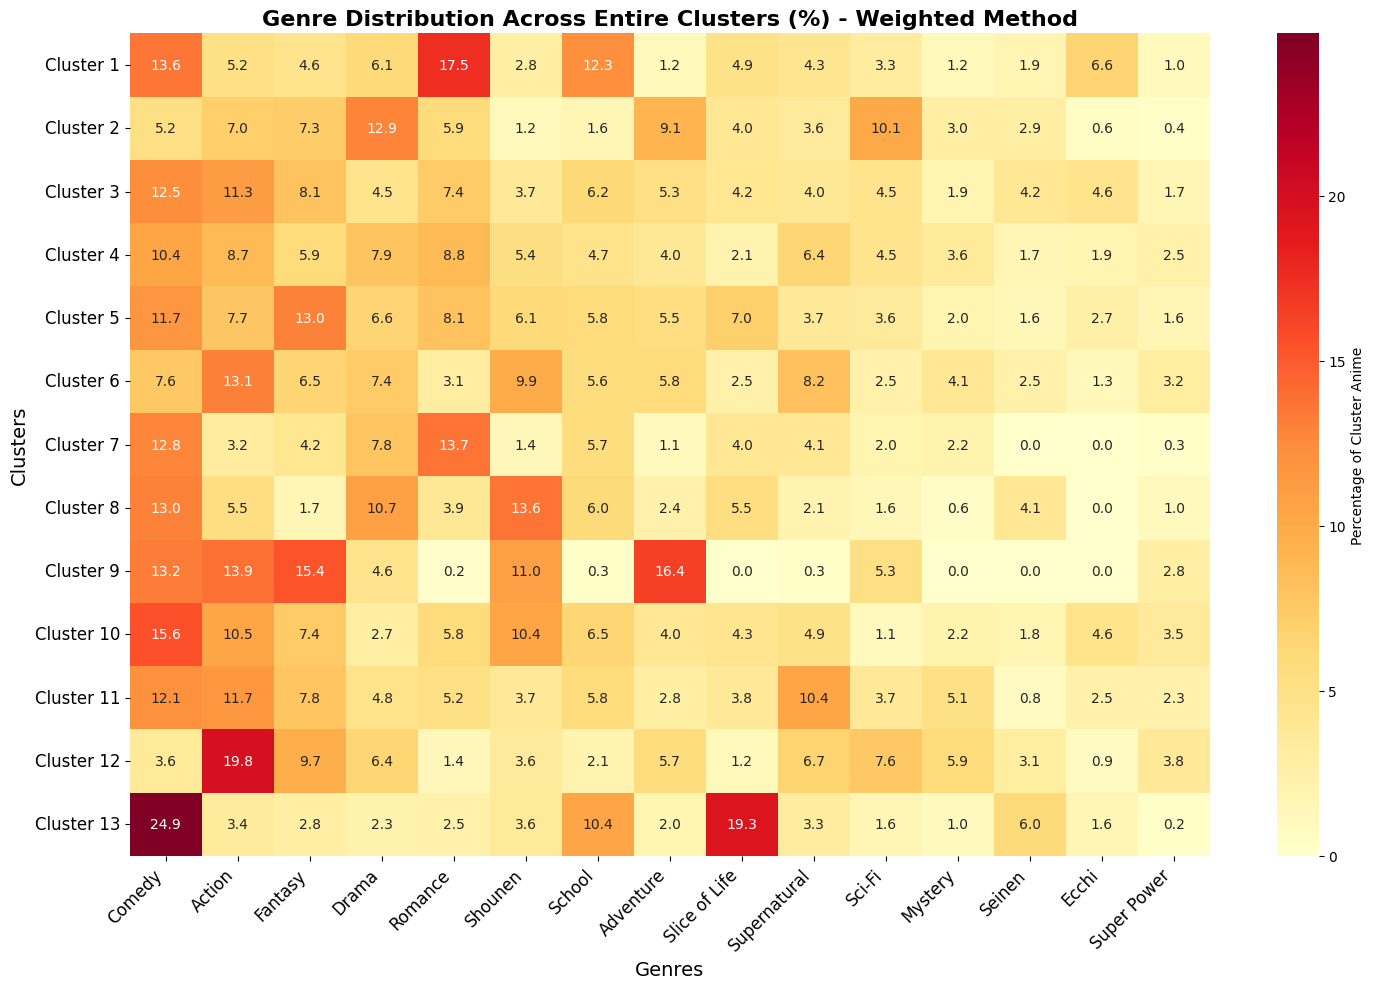


Analyzing genre combinations within clusters...
Analyzing genre combinations...

--- CLUSTER 1 GENRE COMBINATIONS ---
Total anime: 245
Unique genre combinations: 181
Top combinations (≥5 anime):
    2.4% (  6) - Comedy|Ecchi|Harem|Romance|School
    2.0% (  5) - Drama|Romance|School
    2.0% (  5) - Comedy|Romance|Slice of Life

--- CLUSTER 2 GENRE COMBINATIONS ---
Total anime: 127
Unique genre combinations: 114
Top combinations (≥5 anime):

--- CLUSTER 3 GENRE COMBINATIONS ---
Total anime: 165
Unique genre combinations: 138
Top combinations (≥5 anime):
    3.0% (  5) - Adventure|Fantasy

--- CLUSTER 4 GENRE COMBINATIONS ---
Total anime: 160
Unique genre combinations: 143
Top combinations (≥5 anime):

--- CLUSTER 5 GENRE COMBINATIONS ---
Total anime: 178
Unique genre combinations: 141
Top combinations (≥5 anime):
    2.8% (  5) - Action|Adventure|Fantasy

--- CLUSTER 6 GENRE COMBINATIONS ---
Total anime: 204
Unique genre combinations: 140
Top combinations (≥5 anime):
    2.9% (  6) - 

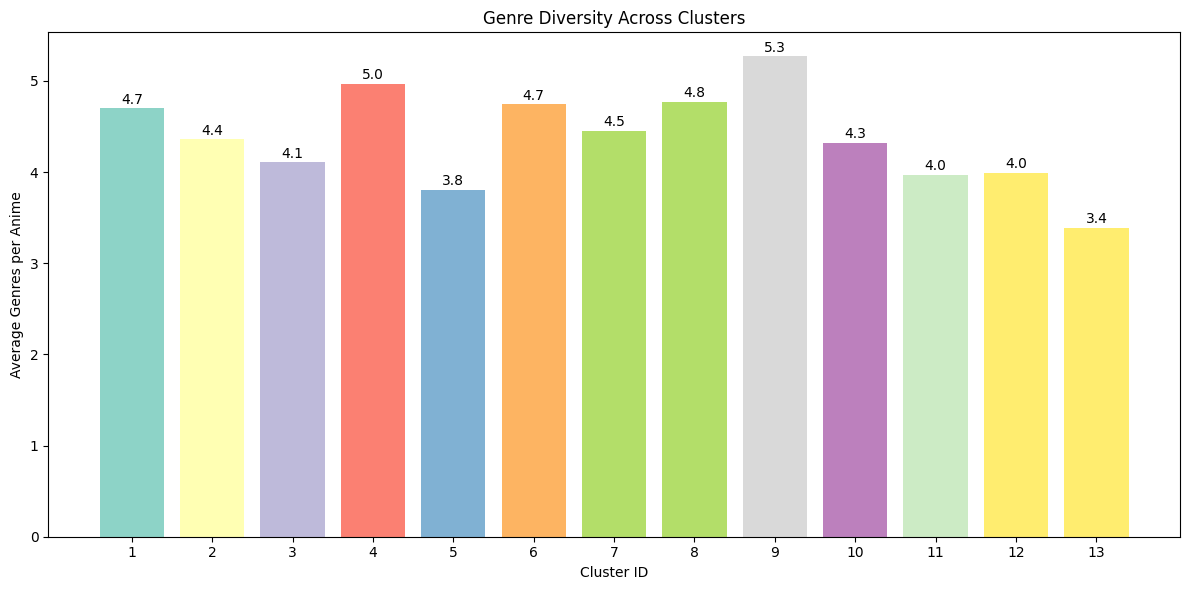


Analyzing genre contexts and semantic relationships...
Analyzing genre contexts and combinations...

GENRE CONTEXT ANALYSIS

--- CLUSTER 1 CONTEXTS ---
Total anime: 245

Top Genre Contexts:
   49.0% - High School Life
   49.0% - Light Comedy
   37.7% - Adult Comedy
   11.7% - Historical Drama
   11.6% - Sports Competition

Top Genre Pairs:
   48.6% (119) - Romance + School
   46.5% (114) - Comedy + Romance
   38.8% (95) - Comedy + School
   29.0% (71) - Harem + Romance
   28.6% (70) - Comedy + Ecchi
   28.6% (70) - Comedy + Harem
   26.5% (65) - Ecchi + Romance
   26.1% (64) - Ecchi + Harem
   23.7% (58) - Harem + School
   22.9% (56) - Ecchi + School

--- CLUSTER 2 CONTEXTS ---
Total anime: 127

Top Genre Contexts:
   21.1% - Mecha Action
   17.9% - Dark Action
   15.2% - Dark Fantasy
   14.8% - Battle Shounen
   12.0% - Serious Drama

Top Genre Pairs:
   24.4% (31) - Drama + Sci-Fi
   22.0% (28) - Action + Sci-Fi
   18.1% (23) - Action + Drama
   17.3% (22) - Action + Adventure
   1

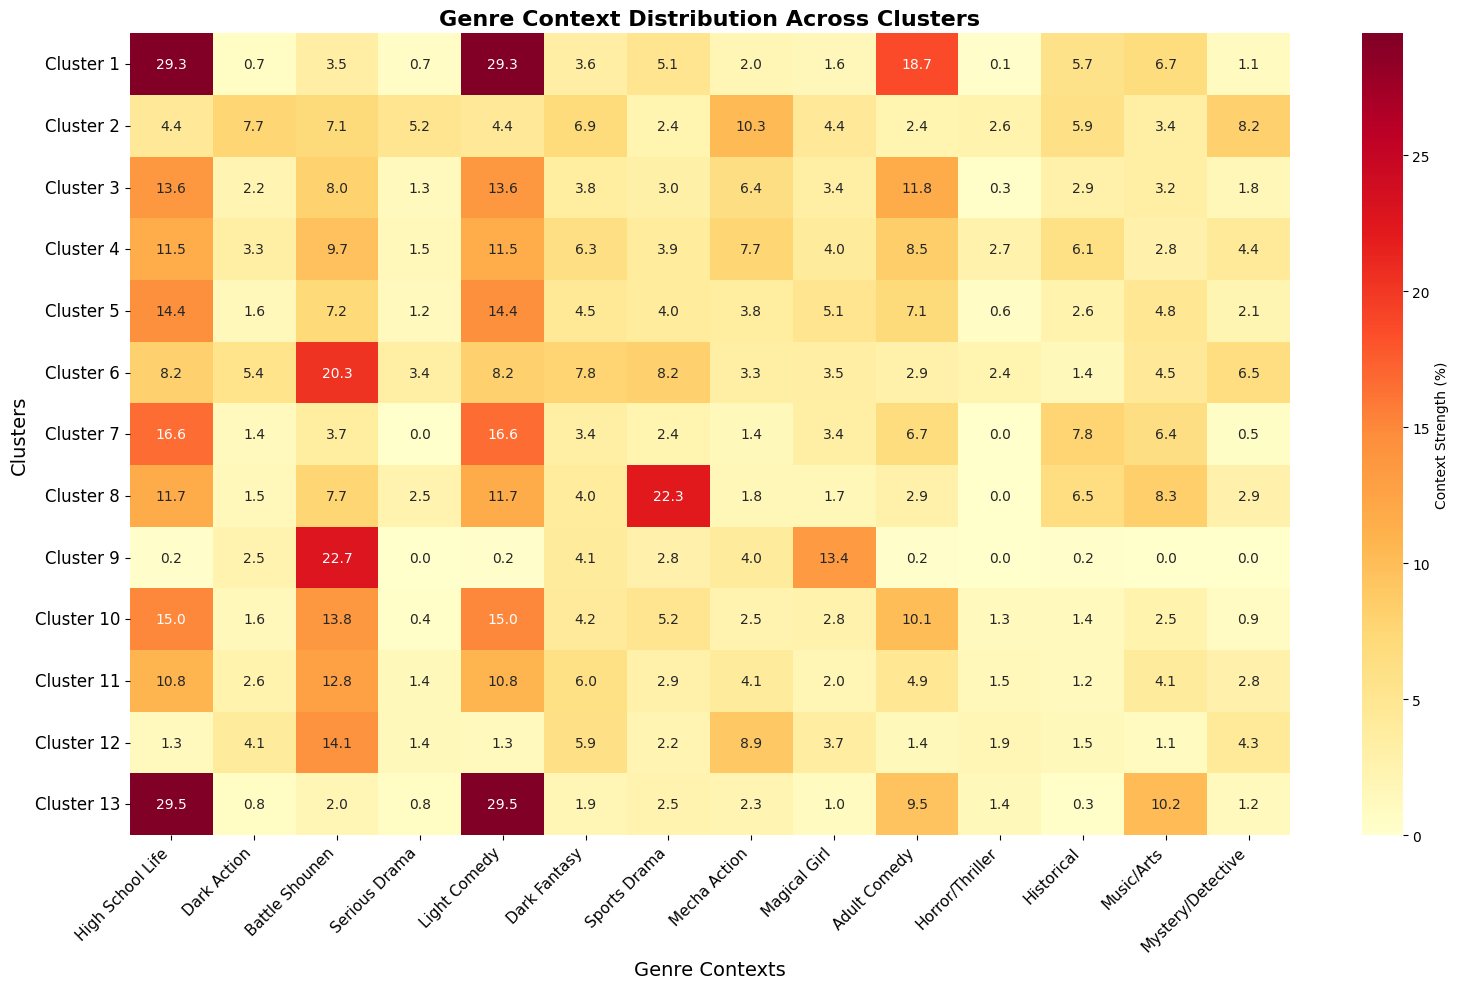


CLEAN CLUSTER ANALYSIS
Creating clean cluster summary...

CLEAN CLUSTER SUMMARY

🎯 CLUSTER 1 (245 anime)
   Primary Type: Romance + Comedy + School
   Best Archetype Match: Adult Romance (6.9)
   Top Genres: Romance (76.7%), Comedy (61.6%), School (57.1%)
   Common Combinations:
     • Comedy + Ecchi + Romance (6.9%)
     • Comedy + Romance + Slice of Life (6.1%)
     • Comedy + Drama + Romance (4.9%)

🎯 CLUSTER 2 (127 anime)
   Primary Type: Drama + Sci-Fi + Action
   Best Archetype Match: Dark Fantasy (2.8)
   Top Genres: Drama (53.5%), Sci-Fi (44.1%), Action (34.6%)
   Common Combinations:
     • Action + Drama + Sci-Fi (6.3%)
     • Action + Adventure + Drama (4.7%)
     • Action + Adventure + Comedy (3.9%)

🎯 CLUSTER 3 (165 anime)
   Primary Type: Comedy + Action + Romance
   Best Archetype Match: Dark Fantasy (3.0)
   Top Genres: Comedy (46.7%), Action (43.6%), Romance (32.1%)
   Common Combinations:
     • Comedy + Ecchi + Romance (5.5%)
     • Action + Adventure + Comedy (4.2%

In [21]:
# Example paths - replace with your actual file paths
clustering_file = r"..\data\spectral\spectral_13_clusters.csv"  # Your clustering results
anime_file = r"..\data\anime.csv"               # Your anime metadata
# Find representatives
representatives = find_cluster_representatives(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    top_n_per_cluster=5,      # Top 5 per cluster
    min_score_count=100,      # At least 100 ratings
    weight_score=0.7,         # 70% weight on score
    weight_popularity=0.3     # 30% weight on popularity
)

# Save results
save_representatives_to_csv(representatives, "cluster_representatives.csv")

# Analyze cluster characteristics
analyze_cluster_characteristics(representatives)

print("\nCreating genre comparison heatmap for entire clusters...")
create_genre_comparison_heatmap_full_clusters(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    save_path="cluster_genre_heatmap_weighted.png",
    top_n_genres=15,
    genre_weighting='weighted'
)

print("\nAnalyzing genre combinations within clusters...")
analyze_genre_combinations(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    top_n_combinations=10,
    min_occurrence=5  # Show combinations that appear in ≥5 anime
)

print("\nAnalyzing genre diversity across clusters...")
create_genre_diversity_analysis(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    save_path="cluster_genre_diversity.png"
)

# NEW: Context-aware analysis (uses predefined contexts - some bias)
print("\nAnalyzing genre contexts and semantic relationships...")
analyze_genre_contexts(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    min_pair_occurrence=10
)

print("\nCreating genre context heatmap...")
create_genre_context_heatmap(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    save_path="cluster_genre_contexts.png"
)

# CLEAN, INTERPRETABLE ANALYSIS (recommended!)
print("\n" + "="*50)
print("CLEAN CLUSTER ANALYSIS")
print("="*50)

# Get clean, digestible summaries
create_clean_cluster_summary(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file,
    save_path="cluster_summary.txt"
)

# Simple one-line descriptions
get_cluster_one_liner_summaries(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file
)

# Simple pattern analysis (no word-splitting bugs!)
create_simple_genre_patterns(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file
)

# Find distinctive genre signatures for each cluster
get_ultra_simple_cluster_names(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file
)

# DEBUG: Why is "Dark Fantasy" dominating?
print("\n" + "="*50)
print("DEBUGGING ARCHETYPE BIAS")
print("="*50)

# Debug a few clusters that were labeled "Dark Fantasy"
debug_archetype_scoring(clustering_file, anime_file, cluster_id=2)
debug_archetype_scoring(clustering_file, anime_file, cluster_id=5)

# Compare old vs new scoring
compare_old_vs_new_scoring(clustering_file, anime_file)

# Compare approaches
compare_archetype_vs_data_driven(
    clustering_file_path=clustering_file,
    anime_file_path=anime_file
)
    